In [548]:
# Utilise ce fichier pour :

#  Étape 2 (préparation)
#  Étape 3 (entraînement)

In [549]:
# Étape 2 : préparation des données

In [550]:
# Cellule 1 — Charger dataset fusionné

import pandas as pd

df = pd.read_csv("C:/Users/REDA/ai-saas-platform/data/processed/churn_with_sentiment.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,text,sentiment_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Service is flexible but could be better,0.096578
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Very happy with the service,0.026613
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Service is flexible but could be better,0.096578
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Very happy with the service,0.026613
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Service is flexible but could be better,0.096578


In [551]:
# Cellule 2 — Analyse rapide

print(df.info())

print("\nValeurs manquantes :")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [552]:
# Cellule 3 — Nettoyage


# supprimer ID inutile
df = df.drop("customerID", axis=1)

# AJOUT IMPORTANT
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [ ]:
# Cellule 4 — Séparer X / y

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------

#  améliorer sentiment
X["sentiment_intensity"] = abs(X["sentiment_score"])

X shape: (7032, 21)
y shape: (7032,)


In [554]:
# Cellule 5 — Supprimer texte (TRÈS IMPORTANT)



# Supprimer texte
X = X.drop("text", axis=1)

# Transformer le score de sentiment en features exploitables
X['sentiment_binary'] = (X['sentiment_score'] > 0).astype(int)  # positif / négatif
X['sentiment_intensity'] = abs(X['sentiment_score'])           # intensité
X['tenure_sentiment'] = X['tenure'] * X['sentiment_score']     # interaction avec durée

In [ ]:
# Cellule 6 — Encodage des variables catégorielles et sélection de features


# Encoder variables catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

# Sauvegarder les colonnes encodées
features_before_selection = X_encoded.columns.tolist()

# Sélection de features pour ne garder que les plus pertinentes
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=200)  # plus de features pour le modèle
X_selected = selector.fit_transform(X_encoded, y)
features_selected = X_encoded.columns[selector.get_support()]


#  Sauvegarder les noms des features sélectionnées
selected_features = X_encoded.columns[selector.get_support()].tolist()
import joblib
joblib.dump(selected_features, "C:/Users/REDA/ai-saas-platform/backend/app/ml/models/churn_features.pkl")
print("Features sauvegardées ✅")


Features sauvegardées ✅


c:\Users\REDA\ai-saas-platform\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=200 is greater than n_features=34. All the features will be returned.
  warnings.warn(
c:\Users\REDA\ai-saas-platform\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [6] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\REDA\ai-saas-platform\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [556]:
# Cellule 7 — Encoder la target (Churn)

y = y.map({"Yes": 1, "No": 0})

print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [557]:



# Cellule 8 — Train / Test split + SMOTE

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Train shape avant SMOTE:", X_train.shape)
print("Test shape:", X_test.shape)

# Appliquer SMOTE sur X_train pour corriger le déséquilibre
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Train shape après SMOTE:", X_train.shape)


Train shape avant SMOTE: (5625, 34)
Test shape: (1407, 34)


Train shape après SMOTE: (8260, 34)


In [558]:
# # Cellule 9 — Sauvegarder les features


# X est le DataFrame encodé avant SMOTE
features = X.columns.tolist()

import joblib
# joblib.dump(features, "C:/Users/REDA/ai-saas-platform/backend/app/ml/models/churn_features.pkl")

joblib.dump(features_before_selection, "C:/Users/REDA/ai-saas-platform/backend/app/ml/models/churn_features.pkl")


print("Features sauvegardées ✅")

Features sauvegardées ✅


In [559]:
# Étape 3 : entraînement du modèle

In [560]:
# Cellule 1 — Imports

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [561]:
# Cellule 2 — Charger dataset fusionné

df = pd.read_csv("C:/Users/REDA/ai-saas-platform/data/processed/churn_with_sentiment.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,text,sentiment_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Service is flexible but could be better,0.096578
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Very happy with the service,0.026613
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Service is flexible but could be better,0.096578
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Very happy with the service,0.026613
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Service is flexible but could be better,0.096578


In [562]:
# Cellule 3 — Nettoyage

# supprimer ID inutile
df = df.drop("customerID", axis=1)

# séparer X / y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# supprimer texte (important)
X = X.drop("text", axis=1)

In [563]:
# Cellule 4 — Encodage

# encoder variables catégorielles
X = pd.get_dummies(X, drop_first=True)

# encoder target
y = y.map({"Yes": 1, "No": 0})

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (7043, 6560)
y distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [564]:
# Cellule 5 — Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [565]:
# Cellule 6 — Entraînement (CORRECTION IMBALANCE)

from imblearn.over_sampling import SMOTE



# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Entraîner le modèle
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    # n_estimators=100,
    # max_depth=None,
    # class_weight="balanced",
    # random_state=42

    n_estimators=500,         # plus d’arbres = meilleure stabilité
    max_depth=None,            # pas de limite, mais limité par min_samples_leaf
    min_samples_split=5,       # évite overfitting
    min_samples_leaf=2,        # chaque feuille doit avoir au moins 2 échantillons
    max_features='sqrt',       # sqrt(p) features par split = meilleure généralisation
    class_weight='balanced',   # pour corriger le déséquilibre
    random_state=42
)
model.fit(X_train_res, y_train_res)


print("Modèle entraîné ✅")

Modèle entraîné ✅


In [566]:
# Cellule 7 — Évaluation complète (PRO)



from sklearn.metrics import classification_report, confusion_matrix

y_proba = model.predict_proba(X_test)[:, 1]

# Tester différents thresholds
# thresholds = [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

thresholds = [0.45]


for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    print(f"\n🔹 Threshold = {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


🔹 Threshold = 0.45
Accuracy: 0.7452093683463449
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1036
           1       0.51      0.85      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409

Confusion Matrix:
 [[733 303]
 [ 56 317]]


In [567]:
# Cellule — Entraînement XGBoost

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Modèle XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # déjà équilibré via SMOTE
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_res, y_train_res)

print("XGBoost entraîné ✅")

XGBoost entraîné ✅


In [568]:
# Cellule — Évaluation avec threshold

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_proba = xgb_model.predict_proba(X_test)[:, 1]

# threshold optimal (tu peux ajuster)
threshold = 0.45

y_pred = (y_proba > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7814052519517388

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1036
           1       0.57      0.68      0.62       373

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409


Confusion Matrix:
[[847 189]
 [119 254]]


In [569]:
# Cellule — Entraînement LightGBM

from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Modèle LightGBM
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

lgb_model.fit(X_train_res, y_train_res)

print("LightGBM entraîné ✅")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4138, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 434
[LightGBM] [Info] Number of data points in the train set: 8276, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [570]:
#  Cellule — Évaluation

y_proba = lgb_model.predict_proba(X_test)[:, 1]

threshold = 0.45

y_pred = (y_proba > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7792760823278921

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.57      0.69      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409


Confusion Matrix:
[[841 195]
 [116 257]]


In [571]:
models = {
    "RandomForest": model,
    "XGBoost": xgb_model
    
}

threshold = 0.45

for name, m in models.items():
    y_proba = m.predict_proba(X_test)[:, 1]
    y_pred = (y_proba > threshold).astype(int)
    
    print(f"\n🔥 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔥 RandomForest
Accuracy: 0.7452093683463449
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1036
           1       0.51      0.85      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409


🔥 XGBoost
Accuracy: 0.7814052519517388
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1036
           1       0.57      0.68      0.62       373

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



In [572]:
models = {

    "LightGBM": lgb_model
}

threshold = 0.45

for name, m in models.items():
    y_proba = m.predict_proba(X_test)[:, 1]
    y_pred = (y_proba > threshold).astype(int)
    
    print(f"\n🔥 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔥 LightGBM
Accuracy: 0.7792760823278921
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.57      0.69      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



In [573]:
# Cellule — Voting Classifier - Combiner avec voting

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
lgb = LGBMClassifier(n_estimators=200, random_state=42)

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgb', lgb)
    ],
    voting='soft'  # 🔥 important (probabilités)
)

ensemble.fit(X_train_res, y_train_res)

print("Ensemble entraîné ✅")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4138, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 434
[LightGBM] [Info] Number of data points in the train set: 8276, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Ensemble entraîné ✅


In [574]:
# Évaluation

y_proba = ensemble.predict_proba(X_test)[:, 1]

threshold = 0.45
y_pred = (y_proba > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7863733144073811
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1036
           1       0.59      0.65      0.62       373

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.74      1409
weighted avg       0.80      0.79      0.79      1409

[[864 172]
 [129 244]]


In [575]:
# Cellule — Stacking - combiner avec Stacking

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)),
    ('lgb', LGBMClassifier(n_estimators=200, random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_res, y_train_res)

print("Stacking entraîné ✅")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4138, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 434
[LightGBM] [Info] Number of data points in the train set: 8276, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3310, number of negative: 3310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 432
[LightGBM] [I

In [576]:
# Évaluation

y_proba = stack_model.predict_proba(X_test)[:, 1]

# threshold = 0.45
threshold = 0.4
# threshold = 0.35
# threshold = 0.38
# threshold = 0.42

y_pred = (y_proba > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


#  Meilleur global : threshold = 0.40
#  Plus safe (precision) : threshold = 0.42
# Plus agressif (recall) : threshold = 0.35

Accuracy: 0.801277501774308
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1036
           1       0.61      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

[[879 157]
 [123 250]]


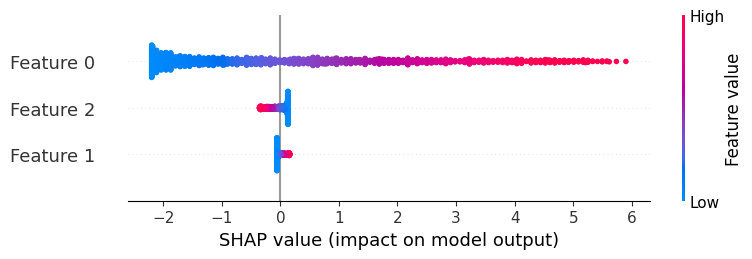

In [ ]:
# Cellule 8 — Feature Importance 



from sklearn.ensemble import StackingClassifier
import shap

# Extraire le final estimator
final_model = stack_model.final_estimator_

# Générer les features transformées par les sous-modèles pour X_train
X_train_transformed = stack_model.transform(X_train)

# # Donner des noms personnalisés
# feature_names = [f"model_{i}" for i in range(X_train_transformed.shape[1])]


# SHAP explainer sur le final estimator
explainer = shap.Explainer(final_model, X_train_transformed)
shap_values = explainer(stack_model.transform(X_test))

# Visualisation globale
shap.summary_plot(shap_values, stack_model.transform(X_test))
# shap.summary_plot(shap_values, stack_model.transform(X_test), feature_names=feature_names)

In [ ]:
# Cellule 9 — Sauvegarde modèle



import joblib

joblib.dump(stack_model, 
            "C:/Users/REDA/ai-saas-platform/backend/app/ml/models/churn_stacking_model.pkl")

print("Stacking model sauvegardé ✅")

Stacking model sauvegardé ✅


In [579]:
# # Cellule 10 — Sauvegarde features 



selected_features = X_encoded.columns[selector.get_support()].tolist()

import joblib
joblib.dump(selected_features, 
            "C:/Users/REDA/ai-saas-platform/backend/app/ml/models/churn_features.pkl")

print("Features sauvegardées ✅")

Features sauvegardées ✅
